I did the mini project with a huge help of Nicholas Renotte's tutorial (nicknochnack on GitHub)



**Install libraries if needed**

In [ ]:
!pip install tensorflow opencv-python matplotlib

Importing Libraries

In [4]:
import tensorflow as tf
import os
import cv2
import imghdr
import numpy as np
from matplotlib import pyplot as plt

In [11]:
# Our data folder with 2 classes (folders)
data_dir = 'Data'

Filtering images

In [12]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

Image not in ext list Data/Billy/e992e9d290f6c77dc8011feb5a1beaba.webp
Issue with image Data/Billy/.ipynb_checkpoints
Image not in ext list Data/Billy/m67n1vbwjik61.webp
Image not in ext list Data/Billy/250px-Billy_Herrington.jpg


Loading our data

In [15]:
# Loading data from our folder. i set batch size very low because i dont have many pictures to feed the model. By default batch size is 32.
data = tf.keras.utils.image_dataset_from_directory('Data', batch_size=4)

Found 56 files belonging to 2 classes.


In [18]:
# Allowing us to iterate through the data and view it
data_iterator = data.as_numpy_iterator()

In [20]:
# Iterate through batch
batch = data_iterator.next()

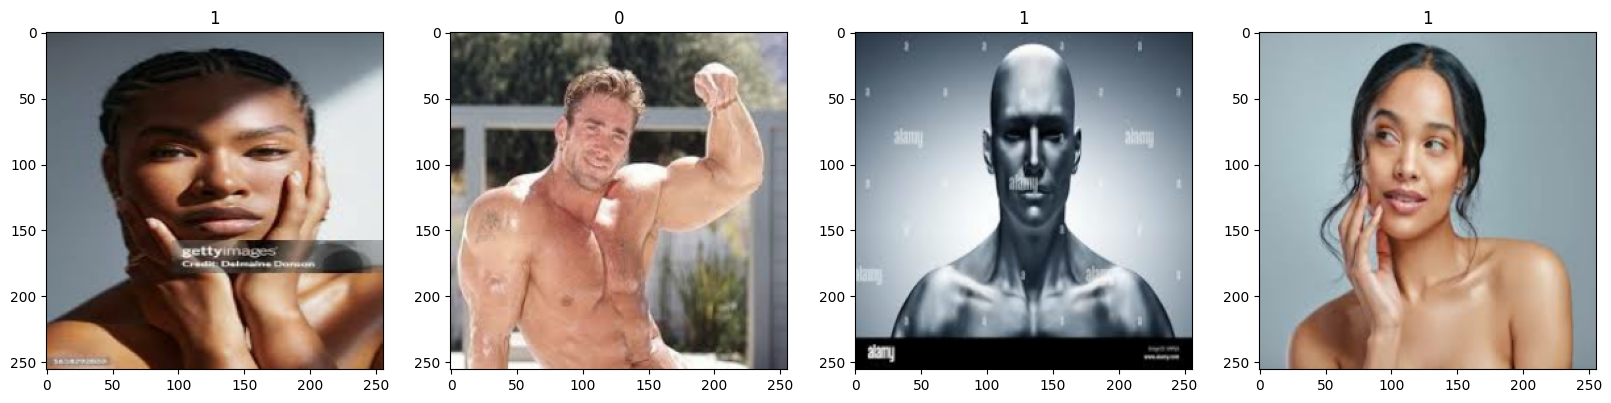

In [21]:
# Quick preview
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# Look out for which class is 1 and which is 0, in my case Billy Herington class is 0, which means 1 is everything thats not Billy

Scaling the data

In [22]:
# By default image values are ranged from 0 to 255 which is not ifficient when training models. We scaling it to range from 0 to 1.

# Data needs to be scaled during model training to ensure all features contribute equally, prevent variables with larger magnitudes from dominating,
# and improve the speed and stability of gradient descent convergence

data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()

(array([[[[0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          ...,
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295]],
 
         [[0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          ...,
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295]],
 
         [[0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          ...,
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295],
          [0.69411767, 0.8352941 , 0.88235295]],
 
         ...,
 
         [[0.70064336, 0.8378983 , 0.8614277 ],
          [0.70009

Splitting the data

In [23]:
# Amount of batches
len(data)

14

In [24]:
# Choosing batch size affects this point because if we have too little batches we might end up having 0 in one of the splits. If that happens we can manually add or substract batches from our splits.
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

train_size, val_size, test_size

(9, 2, 1)

In [25]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

Building the model

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [27]:
# Initializing the model we will be using
model = Sequential()

In [28]:
# Dont know what happens here
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [30]:
# Choosing folder for the logs
logdir='logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [31]:
# Training the model
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - accuracy: 0.4156 - loss: 0.9432 - val_accuracy: 0.7500 - val_loss: 0.6288
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.4884 - loss: 0.6785 - val_accuracy: 0.3750 - val_loss: 0.8060
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.7305 - loss: 0.5320 - val_accuracy: 0.8750 - val_loss: 0.3822
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.7071 - loss: 0.6331 - val_accuracy: 0.7500 - val_loss: 0.4741
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - accuracy: 0.6510 - loss: 0.5540 - val_accuracy: 0.7500 - val_loss: 0.4341
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.8001 - loss: 0.4399 - val_accuracy: 0.7500 - val_loss: 0.6085
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.7958 - loss: 0.4977 - val_accuracy: 0.8750 - val_loss: 0.1625
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.9498 - loss: 0.1937 - val_accuracy: 1.0000 - val_loss:

Model's performance

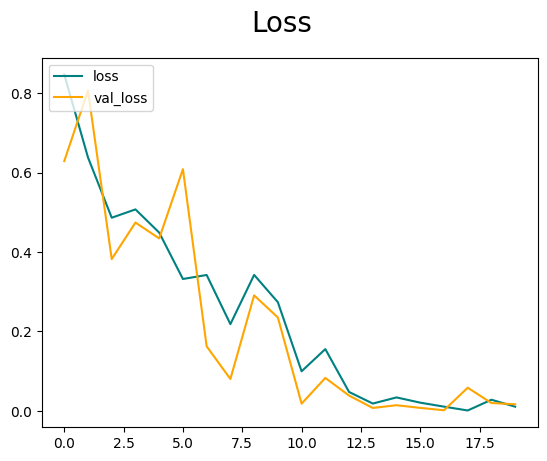

In [32]:
# Loss graph
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

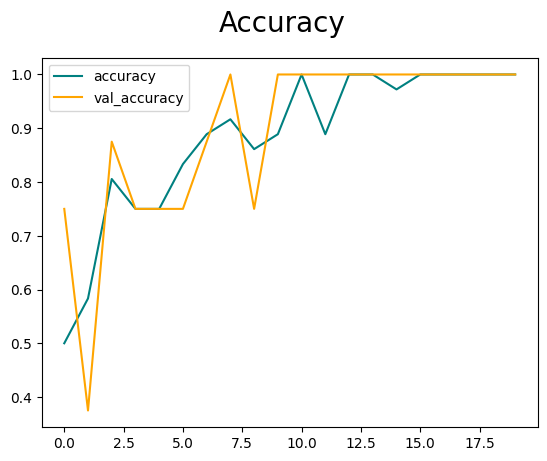

In [33]:
# Accuracy graph
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [34]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [35]:
# Metrics
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

print(pre.result(), re.result(), acc.result())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


Testing

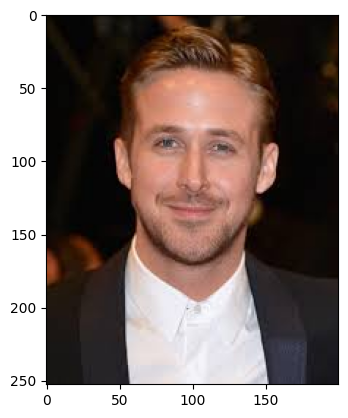

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Not Billy Herington


In [48]:
# Test 1
img = cv2.imread('RyanTest.jpg')
colored = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resize = tf.image.resize(img, (256,256))
plt.imshow(colored.astype(int))
plt.show()

yhat = model.predict(np.expand_dims(resize/255, 0))

if yhat > 0.5:
    print(f'Billy Herington')
else:
    print(f'Not Billy Herington')


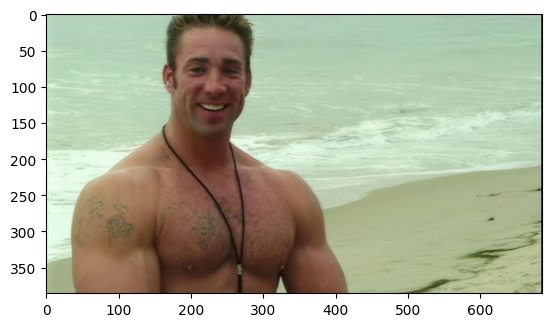

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Billy Herington


In [47]:
# Test 2
img = cv2.imread('BillyTest.jpg')
colored = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resize = tf.image.resize(img, (256,256))
plt.imshow(colored.astype(int))
plt.show()

yhat = model.predict(np.expand_dims(resize/255, 0))

if yhat > 0.5:
    print(f'Billy Herington')
else:
    print(f'Not Billy Herington')

Saving the model

In [50]:
from tensorflow.keras.models import load_model

In [51]:
model.save(os.path.join('models','BillyDistinguisher.h5'))

In [52]:
new_model = load_model('BillyDistinguisher.h5')

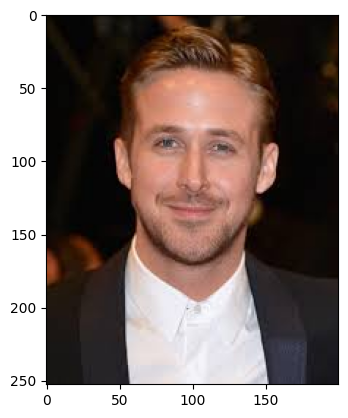

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Not Billy Herington


In [55]:
img = cv2.imread('RyanTest.jpg')
colored = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resize = tf.image.resize(img, (256,256))
plt.imshow(colored.astype(int))
plt.show()

yhat = new_model.predict(np.expand_dims(resize/255, 0))

if yhat > 0.5:
    print(f'Billy Herington')
else:
    print(f'Not Billy Herington')